

# Loan Default Probability 

The goal of this case study is to build a machine learning model to predict the probability that a loan will default.

## Content

* [1. Problem Definition](#0)
* [2. Getting Started - Load Libraries and Dataset](#1)
    * [2.1. Load Libraries](#1.1)    
    * [2.2. Load Dataset](#1.2)
* [3. Data Preparation and Feature Selection](#2)
    * [3.1. Preparing the predicted variable](#2.1)    
    * [3.2. Feature Selection-Limit the Feature Space](#2.2)
        * [3.2.1.  Features elimination by significant missing values ](#2.2.1)
        * [3.2.2.  Features elimination based on the intutiveness](#2.2.2)
        * [3.2.3.  Features elimination based on the correlation](#2.2.3)   
* [4. Feature Engineering and Exploratory Analysis](#3)
    * [4.1 Feature Analysis and Exploration](#3.1)
        * [4.1.1. Analysing the categorical features](#3.1.1)
        * [4.1.2  Analysing the continuous features ](#3.1.2) 
    * [4.2.Encoding Categorical Data](#3.2)
    * [4.3.Sampling Data](#3.3)    
* [5.Evaluate Algorithms and Models](#4)        
    * [5.1. Train/Test Split](#4.1)
    * [5.2. Test Options and Evaluation Metrics](#4.2)
    * [5.3. Compare Models and Algorithms](#4.3)
* [6. Model Tuning and Grid Search](#5)  
* [7. Finalize the Model](#6)  
    * [7.1. Results on test dataset](#6.1)
    * [7.1. Variable Intuition/Feature Selection](#6.2) 
    * [7.3. Save model for later use](#6.3)


<a id='0'></a>
# 1. Problem Definition

The problem is defined in the classification framework, where the predicted variable
is “Charge-Off ”. A charge-off is a debt that a creditor has given up trying to collect on
after you’ve missed payments for several months. The predicted variable takes value 1
in case of charge-off and 0 otherwise.

This case study aims to analyze data for loans through 2007-2017Q3 from Lending Club available on Kaggle. Dataset contains over 887 thousand observations and 150 variables among which one is describing the loan status. 

<a id='1'></a>
# 2. Getting Started- Loading the data and python packages

<a id='1.1'></a>
## 2.1. Loading the python packages

In [58]:
# Load libraries
import numpy as np
import pandas as pd
from matplotlib import pyplot
from pandas import read_csv, set_option
from pandas.plotting import scatter_matrix
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

#Libraries for Deep Learning Models
import tensorflow
from keras.models import Sequential
from keras.layers import Dense
from scikeras.wrappers import KerasClassifier
from keras.optimizers import SGD

#Libraries for Saving the Model
from pickle import dump
from pickle import load

<a id='1.2'></a>
## 2.2. Loading the Data

We load the data in this step.

#### <font color='red'>Note : Due to limit in the github for the data size, a sample of the data has been loaded in the jupyter notebook repository of this book. However, all the subsequent results in this jupyter notebook is with actual data (~1GB) under https://www.kaggle.com/mlfinancebook/lending-club-loans-data. You should load the full data in case you want to reproduce the results. </font> 

In [59]:
# load dataset
loans = pd.read_csv('LoanData.csv',  encoding='utf-8')
#loans = pd.read_csv('LoansData.csv.gz', compression='gzip', low_memory=True) #Use this for the actual data

In [60]:
dataset = loans

In [61]:
#Diable the warnings
import warnings
warnings.filterwarnings('ignore')

In [62]:
type(dataset)

pandas.core.frame.DataFrame

<a id='2'></a>
## 3. Data Preparation and Feature Selection

<a id='2.1'></a>
## 3.1. Preparing the predicted variable


In [63]:
# We're going to try to predict the loan_status variable. What are the value counts for this variable
dataset['loan_status'].value_counts(dropna=False)

loan_status
Current                                                788950
Fully Paid                                             646902
Charged Off                                            168084
Late (31-120 days)                                      23763
In Grace Period                                         10474
Late (16-30 days)                                        5786
Does not meet the credit policy. Status:Fully Paid       1988
Does not meet the credit policy. Status:Charged Off       761
Default                                                    70
NaN                                                        23
Name: count, dtype: int64

We're going to try to learn differences in the features between completed loans that have been fully paid or charged off. We won't consider loans that are current, don't meet the credit policy, defaulted, or have a missing status. So we only keep the loans with status "Fully Paid" or "Charged Off."

In [64]:
dataset = dataset.loc[dataset['loan_status'].isin(['Fully Paid', 'Charged Off'])]

dataset['loan_status'].value_counts(dropna=False)

dataset['loan_status'].value_counts(normalize=True, dropna=False)

loan_status
Fully Paid     0.793758
Charged Off    0.206242
Name: proportion, dtype: float64

About 79% of the remaining loans have been fully paid and 21% have charged off, so we have a somewhat unbalanced classification problem.

In [65]:
dataset['charged_off'] = (dataset['loan_status'] == 'Charged Off').apply(np.uint8)
dataset.drop('loan_status', axis=1, inplace=True)

<a id='2.2'></a>
## 3.2. Feature Selection-Limit the Feature Space 

The full dataset has 150 features for each
loan. We’ll eliminate
features in following steps using three different approaches:
* Eliminate feature that have more than 30% missing values.
* Eliminate features that are unintuitive based on subjective judgement.
* Eliminate features with low correlation with the predicted variable

<a id='2.2.1'></a>
### 3.2.1.  Features elimination by significant missing values

First calculating the percentage of missing data for each feature:

In [66]:
missing_fractions = dataset.isnull().mean().sort_values(ascending=False)

missing_fractions.head(10)

member_id                                     1.000000
next_pymnt_d                                  1.000000
orig_projected_additional_accrued_interest    0.999876
sec_app_mths_since_last_major_derog           0.999628
hardship_length                               0.999275
deferral_term                                 0.999275
hardship_end_date                             0.999275
hardship_reason                               0.999275
hardship_start_date                           0.999275
hardship_type                                 0.999275
dtype: float64

In [67]:
drop_list = sorted(list(missing_fractions[missing_fractions > 0.3].index))
print(drop_list)

['all_util', 'annual_inc_joint', 'debt_settlement_flag_date', 'deferral_term', 'desc', 'dti_joint', 'hardship_amount', 'hardship_dpd', 'hardship_end_date', 'hardship_last_payment_amount', 'hardship_length', 'hardship_loan_status', 'hardship_payoff_balance_amount', 'hardship_reason', 'hardship_start_date', 'hardship_status', 'hardship_type', 'il_util', 'inq_fi', 'inq_last_12m', 'max_bal_bc', 'member_id', 'mths_since_last_delinq', 'mths_since_last_major_derog', 'mths_since_last_record', 'mths_since_rcnt_il', 'mths_since_recent_bc_dlq', 'mths_since_recent_revol_delinq', 'next_pymnt_d', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'open_rv_12m', 'open_rv_24m', 'orig_projected_additional_accrued_interest', 'payment_plan_start_date', 'revol_bal_joint', 'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med', 'sec_app_earliest_cr_line', 'sec_app_fico_range_high', 'sec_app_fico_range_low', 'sec_app_inq_last_6mths', 'sec_app_mort_acc', 'sec_app_mths_since_last_ma

In [68]:
len(drop_list)

58

In [69]:
dataset.drop(labels=drop_list, axis=1, inplace=True)
dataset.shape

(814986, 92)

<a id='2.2.2'></a>
### 3.2.2.  Features elimination based on the intutiveness

In order to filter the features further we check the description in the data dictionary and keep the features that are
intuitive on the basis of subjective judgement. 

We examine the LendingClub website and Data Dictionary to determine which features would have been available to potential investors. Here's the list of features we currently have, in alphabetical order:

In [70]:
print(sorted(dataset.columns))

['acc_now_delinq', 'acc_open_past_24mths', 'addr_state', 'annual_inc', 'application_type', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'charged_off', 'chargeoff_within_12_mths', 'collection_recovery_fee', 'collections_12_mths_ex_med', 'debt_settlement_flag', 'delinq_2yrs', 'delinq_amnt', 'disbursement_method', 'dti', 'earliest_cr_line', 'emp_length', 'emp_title', 'fico_range_high', 'fico_range_low', 'funded_amnt', 'funded_amnt_inv', 'grade', 'hardship_flag', 'home_ownership', 'id', 'initial_list_status', 'inq_last_6mths', 'installment', 'int_rate', 'issue_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'last_pymnt_amnt', 'last_pymnt_d', 'loan_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sa

The list that is kept is as follows: 

In [71]:
keep_list = ['charged_off','funded_amnt','addr_state', 'annual_inc', 'application_type', 'dti', 'earliest_cr_line', 'emp_length', 'emp_title', 'fico_range_high', 'fico_range_low', 'grade', 'home_ownership', 'id', 'initial_list_status', 'installment', 'int_rate', 'loan_amnt', 'loan_status', 'mort_acc', 'open_acc', 'pub_rec', 'pub_rec_bankruptcies', 'purpose', 'revol_bal', 'revol_util', 'sub_grade', 'term', 'title', 'total_acc', 'verification_status', 'zip_code','last_pymnt_amnt','num_actv_rev_tl', 'mo_sin_rcnt_rev_tl_op','mo_sin_old_rev_tl_op',"bc_util","bc_open_to_buy","avg_cur_bal","acc_open_past_24mths" ]

len(keep_list)

40

In [72]:
drop_list = [col for col in dataset.columns if col not in keep_list]

dataset.drop(labels=drop_list, axis=1, inplace=True)

dataset.shape

(814986, 39)

<a id='2.2.3'></a>
### 3.2.3.  Features elimination based on the correlation

In [73]:
# Sélection des colonnes numériques seulement
numeric_columns = dataset.select_dtypes(include=['number']).columns
dataset_numeric = dataset[numeric_columns]

# Calcul de la corrélation
correlation = dataset_numeric.corr()
correlation_chargeOff = abs(correlation['charged_off'])


In [74]:
correlation_chargeOff.sort_values(ascending=False)

charged_off              1.000000
last_pymnt_amnt          0.381359
int_rate                 0.247815
fico_range_low           0.139430
fico_range_high          0.139428
dti                      0.123031
acc_open_past_24mths     0.098985
bc_open_to_buy           0.086896
avg_cur_bal              0.085777
num_actv_rev_tl          0.077211
bc_util                  0.077132
mort_acc                 0.077086
revol_util               0.072185
funded_amnt              0.064258
loan_amnt                0.064139
mo_sin_rcnt_rev_tl_op    0.053469
mo_sin_old_rev_tl_op     0.048529
annual_inc               0.046685
installment              0.046291
open_acc                 0.034652
pub_rec                  0.023105
pub_rec_bankruptcies     0.017314
revol_bal                0.013160
total_acc                0.011187
Name: charged_off, dtype: float64

In [75]:
drop_list_corr = sorted(list(correlation_chargeOff[correlation_chargeOff < 0.03].index))
print(drop_list_corr)

['pub_rec', 'pub_rec_bankruptcies', 'revol_bal', 'total_acc']


In [76]:
dataset.drop(labels=drop_list_corr, axis=1, inplace=True)
dataset.shape

(814986, 35)

<a id='3'></a>
# 4. Feature Engineering and Exploratory Analysis

In [77]:
#Descriptive Statistics
dataset.describe()

,loan_amnt,funded_amnt,int_rate,installment,annual_inc,dti,fico_range_low,fico_range_high,open_acc,revol_util,last_pymnt_amnt,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mort_acc,num_actv_rev_tl,charged_off
count,814986.000000,814986.000000,814986.000000,814986.000000,8.149860e+05,814950.000000,814986.000000,814986.000000,814986.000000,814496.000000,814986.000000,767705.000000,747447.000000,759810.00000,759321.000000,747458.000000,747458.000000,767705.000000,747459.000000,814986.000000
mean,14315.458210,14301.566929,13.490993,436.749624,7.523039e+04,17.867719,695.603151,699.603264,11.521099,53.031137,5918.144144,4.716176,13519.786576,9464.94483,61.575664,180.843182,12.705577,1.758707,5.658872,0.206242
std,8499.799241,8492.964986,4.618486,255.732093,6.524373e+04,8.856477,31.352251,31.352791,5.325064,24.320981,7279.949481,3.152369,16221.882463,14575.87033,27.871170,92.192939,15.654277,2.081730,3.215863,0.404606
min,500.000000,500.000000,5.320000,4.930000,0.000000e+00,-1.000000,625.000000,629.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,8000.000000,8000.000000,9.990000,251.400000,4.500000e+04,11.640000,670.000000,674.000000,8.000000,35.000000,446.922500,2.000000,3119.000000,1312.00000,40.800000,117.000000,4.000000,0.000000,3.000000,0.000000
50%,12000.000000,12000.000000,13.110000,377.040000,6.500000e+04,17.360000,690.000000,694.000000,11.000000,53.700000,2864.715000,4.000000,7508.000000,4261.00000,65.400000,164.000000,8.000000,1.000000,5.000000,0.000000
75%,20000.000000,20000.000000,16.290000,576.290000,9.000000e+04,23.630000,710.000000,714.000000,14.000000,71.900000,9193.050000,6.000000,18827.000000,11343.00000,86.000000,228.000000,15.000000,3.000000,7.000000,0.000000
max,40000.000000,40000.000000,30.990000,1714.540000,9.550000e+06,999.000000,845.000000,850.000000,90.000000,892.300000,42148.530000,56.000000,958084.000000,559912.00000,339.600000,842.000000,372.000000,51.000000,57.000000,1.000000


<a id='3.1'></a>
## 4.1 Feature Analysis and Exploration

<a id='3.1.1'></a>
### 4.1.1. Analysing the categorical features 

In [78]:
dataset[['id','emp_title','title','zip_code']].describe()

,id,emp_title,title,zip_code
count,814986,766415,807067,814986
unique,814986,280473,60297,925
top,66601274,Teacher,Debt consolidation,945xx
freq,1,11351,371874,9517


In [79]:
#Ids are all unique and there are too many job titles and titles and zipcode, 
#these column is dropped The ID is not useful for modeling.
dataset.drop(['id','emp_title','title','zip_code'], axis=1, inplace=True)

#### Feature- Term

In [80]:
#Data Dictionary: "The number of payments on the loan. Values are in months and can be either 36 or 60.". 
#The 60 Months loans are more likelely to charge off
#Convert term to integers
dataset['term'] = dataset['term'].apply(lambda s: np.int8(s.split()[0]))

In [81]:
dataset.groupby('term')['charged_off'].value_counts(normalize=True).loc[:,1]

term
36    0.165710
60    0.333793
Name: proportion, dtype: float64

Loans with five-year periods are more than twice as likely to charge-off as loans with three-year periods.

#### Feature- Employement Length

In [82]:
dataset['emp_length'].replace(to_replace='10+ years', value='10 years', inplace=True)

dataset['emp_length'].replace('< 1 year', '0 years', inplace=True)

def emp_length_to_int(s):
    if pd.isnull(s):
        return s
    else:
        return np.int8(s.split()[0])
    
dataset['emp_length'] = dataset['emp_length'].apply(emp_length_to_int)


<Axes: xlabel='emp_length'>

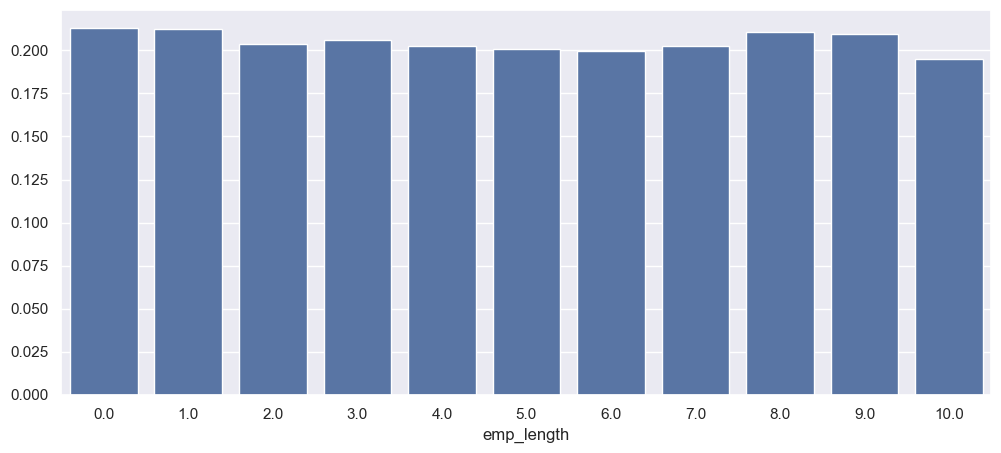

In [83]:
charge_off_rates = dataset.groupby('emp_length')['charged_off'].value_counts(normalize=True).loc[:,1]
sns.barplot(x=charge_off_rates.index, y=charge_off_rates.values, color='#5975A4', saturation=1)

 Loan status does not appear to vary much with employment length on average, hence it is dropped

In [84]:
dataset.drop(['emp_length'], axis=1, inplace=True)

#### Feature : Subgrade

<Axes: xlabel='sub_grade'>

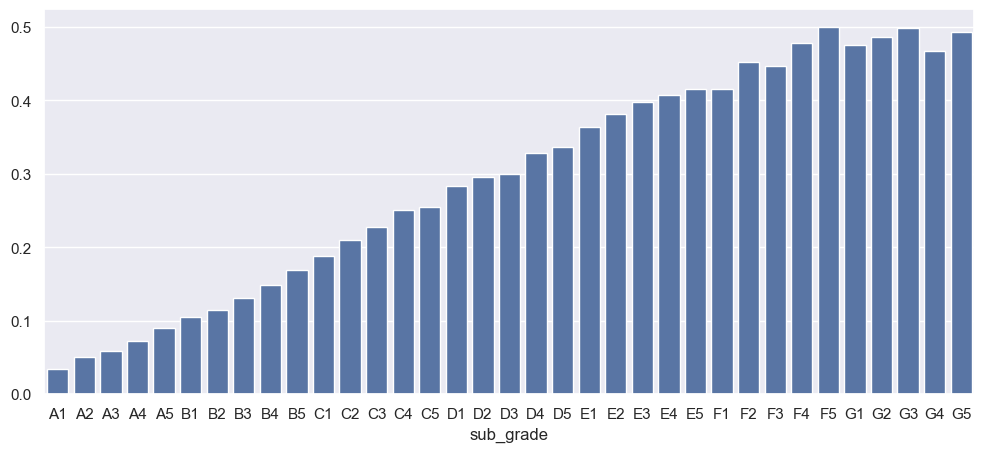

In [85]:
charge_off_rates = dataset.groupby('sub_grade')['charged_off'].value_counts(normalize=True).loc[:,1]
sns.set(rc={'figure.figsize':(12,5)})
sns.barplot(x=charge_off_rates.index, y=charge_off_rates.values, color='#5975A4', saturation=1)


There's a clear trend of higher probability of charge-off as the subgrade worsens.

In [86]:
dataset['earliest_cr_line'] = dataset['earliest_cr_line'].apply(lambda s: int(s[-4:]))

<a id='3.1.2'></a>
### 4.1.2. Analysing the continuous features 

#### Feature : Annual Income

In [87]:
dataset[['annual_inc']].describe()

,annual_inc
count,8.149860e+05
mean,7.523039e+04
std,6.524373e+04
min,0.000000e+00
25%,4.500000e+04
50%,6.500000e+04
75%,9.000000e+04
max,9.550000e+06


Annual income ranges from 0  to  9,550,000, with a median of $65,000. 
Because of the large range of incomes, we should take a log transform of the annual income variable.

In [88]:
dataset['log_annual_inc'] = dataset['annual_inc'].apply(lambda x: np.log10(x+1))
dataset.drop('annual_inc', axis=1, inplace=True)

#### FICO Scores

In [89]:
dataset[['fico_range_low','fico_range_high']].corr()

,fico_range_low,fico_range_high
fico_range_low,1.0,1.0
fico_range_high,1.0,1.0


Given that the correlation between fico low and high is 1 it is preferred to keep only one feature which is average of FICO Scores

In [90]:
dataset['fico_score'] = 0.5*dataset['fico_range_low'] + 0.5*dataset['fico_range_high']

dataset.drop(['fico_range_high', 'fico_range_low'], axis=1, inplace=True)

In [91]:
dataset['charged_off'].value_counts()

charged_off
0    646902
1    168084
Name: count, dtype: int64

<a id='3.2'></a>
## 4.2. Encoding Categorical Data

In [92]:
from sklearn.preprocessing import LabelEncoder

In [93]:
# Categorical boolean mask
categorical_feature_mask = dataset.dtypes==object
# filter categorical columns using mask and turn it into a list
categorical_cols = dataset.columns[categorical_feature_mask].tolist()

In [94]:
categorical_cols

['grade',
 'sub_grade',
 'home_ownership',
 'verification_status',
 'purpose',
 'addr_state',
 'initial_list_status',
 'application_type']

In [95]:
le = LabelEncoder()
# apply le on categorical feature columns
dataset[categorical_cols] = dataset[categorical_cols].apply(lambda col: le.fit_transform(col))
dataset[categorical_cols].head(10)

,grade,sub_grade,home_ownership,verification_status,purpose,addr_state,initial_list_status,application_type
0,2,10,5,1,2,45,1,0
1,0,2,1,0,1,4,1,0
2,3,15,5,1,1,24,1,0
4,2,12,5,1,2,3,0,0
5,2,12,5,1,2,31,0,0
6,1,9,1,1,4,23,0,0
7,1,8,4,2,2,45,1,0
8,2,13,5,1,1,47,0,0
9,1,8,5,0,2,20,0,0
10,1,9,5,2,2,22,0,0


In [96]:
dataset.head(5)

,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,home_ownership,verification_status,purpose,...,avg_cur_bal,bc_open_to_buy,bc_util,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mort_acc,num_actv_rev_tl,charged_off,log_annual_inc,fico_score
0,15000.0,15000.0,60,12.39,336.64,2,10,5,1,2,...,29828.0,9525.0,4.7,244.0,1.0,0.0,4.0,0,4.892100,752.0
1,10400.0,10400.0,36,6.99,321.08,0,2,1,0,1,...,9536.0,7599.0,41.5,290.0,1.0,1.0,9.0,1,4.763435,712.0
2,21425.0,21425.0,60,15.59,516.36,3,15,5,1,1,...,4232.0,324.0,97.8,136.0,7.0,0.0,4.0,0,4.804827,687.0
4,7650.0,7650.0,36,13.66,260.20,2,12,5,1,2,...,5857.0,332.0,93.2,148.0,8.0,0.0,4.0,1,4.698979,687.0
5,9600.0,9600.0,36,13.66,326.53,2,12,5,1,2,...,3214.0,6494.0,69.2,265.0,23.0,0.0,7.0,0,4.838855,682.0


In [97]:
dataset.shape

(814986, 29)

<a id='3.4'></a>
## 4.3. Sampling Data

In [98]:
loanstatus_0 = dataset[dataset["charged_off"]==0]
loanstatus_1 = dataset[dataset["charged_off"]==1]
subset_of_loanstatus_0 = loanstatus_0.sample(n=5500)
subset_of_loanstatus_1 = loanstatus_1.sample(n=5500)
dataset = pd.concat([subset_of_loanstatus_1, subset_of_loanstatus_0])
dataset = dataset.sample(frac=1).reset_index(drop=True)
print("Current shape of dataset :",dataset.shape)
dataset.head()

Current shape of dataset : (11000, 29)


,loan_amnt,funded_amnt,term,int_rate,installment,grade,sub_grade,home_ownership,verification_status,purpose,...,avg_cur_bal,bc_open_to_buy,bc_util,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mort_acc,num_actv_rev_tl,charged_off,log_annual_inc,fico_score
0,12600.0,12600.0,60,22.74,353.33,4,20,5,0,6,...,226.0,78320.0,1.6,118.0,0.0,0.0,7.0,1,5.176094,792.0
1,10000.0,10000.0,36,13.68,340.23,2,10,1,2,2,...,31802.0,16953.0,38.8,28.0,18.0,2.0,4.0,0,4.863329,662.0
2,9250.0,9250.0,36,19.99,343.72,4,20,5,1,2,...,850.0,3563.0,39.6,200.0,3.0,0.0,5.0,1,4.778158,682.0
3,9100.0,9100.0,36,13.24,307.67,3,17,5,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,4.691974,672.0
4,3600.0,3600.0,36,12.29,120.08,2,10,1,1,2,...,15725.0,5732.0,37.7,64.0,12.0,2.0,6.0,1,4.544080,662.0


In [99]:
#Filling the NAs with the mean of the column.
dataset.fillna(dataset.mean(),inplace = True)

<a id='4'></a>
# 5. Evaluate Algorithms and Models

<a id='4.1'></a>
## 5.1. Train Test Split

In [100]:
# split out validation dataset for the end
Y= dataset["charged_off"]
X = dataset.loc[:, dataset.columns != 'charged_off']
validation_size = 0.2
seed = 7
X_train, X_validation, Y_train, Y_validation = train_test_split(X, Y, test_size=validation_size, random_state=seed)

In [101]:
# dataset_temp2=dataset_temp.dropna(axis=0)
# Y_total= dataset_temp2["charged_off"]
# X_total = dataset_temp2.loc[:, dataset.columns != 'charged_off']
# X_dummy, X_validation, Y_dummy, Y_validation = train_test_split(X_total, Y_total, test_size=validation_size)

In [102]:
dataset['charged_off'].value_counts()

charged_off
1    5500
0    5500
Name: count, dtype: int64

<a id='4.2'></a>
## 5.2. Test Options and Evaluation Metrics


In [103]:
# test options for classification
num_folds = 10
seed = 7
#scoring = 'accuracy'
#scoring ='precision'
#scoring ='recall'
scoring = 'roc_auc'

<a id='4.3'></a>
## 5.3. Compare Models and Algorithms

### Classification Models

In [104]:
# spot check the algorithms
models = []
models.append(('LR', LogisticRegression()))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
#Neural Network
models.append(('NN', MLPClassifier()))
#Ensable Models 
# Boosting methods
models.append(('AB', AdaBoostClassifier()))
models.append(('GBM', GradientBoostingClassifier()))
# Bagging methods
models.append(('RF', RandomForestClassifier()))
models.append(('ET', ExtraTreesClassifier()))

### K-folds cross validation

In [105]:
results = []
names = []
for name, model in models:
    kfold = KFold(n_splits=num_folds, shuffle=True, random_state=seed)
    cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

LR: 0.924705 (0.011050)
LDA: 0.922104 (0.009362)
KNN: 0.874358 (0.014219)
CART: 0.846260 (0.011303)
NB: 0.923632 (0.008814)
NN: 0.908882 (0.015406)
AB: 0.943666 (0.008051)
GBM: 0.958341 (0.005888)
RF: 0.951737 (0.006852)
ET: 0.942622 (0.008653)


### Algorithm comparison

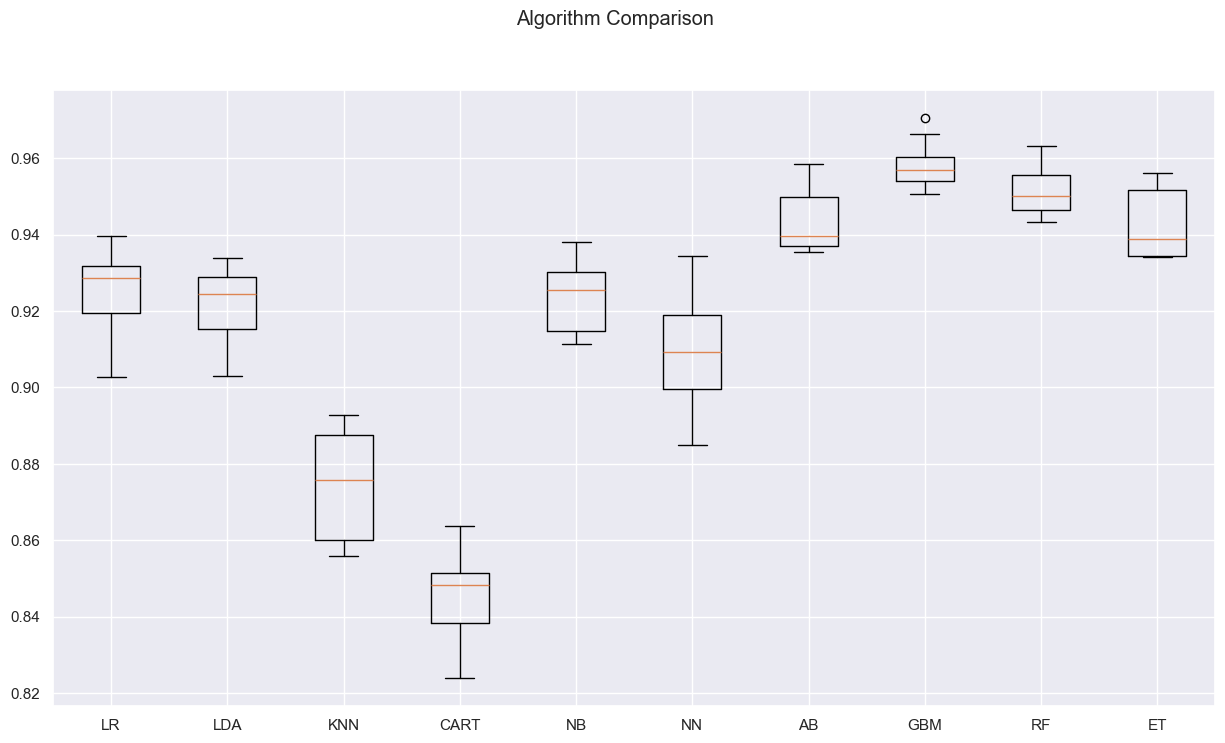

In [106]:
# compare algorithms
fig = pyplot.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
pyplot.boxplot(results)
ax.set_xticklabels(names)
fig.set_size_inches(15,8)
pyplot.show()

<a id='5'></a>
# 6. Model Tuning and Grid Search

Given that the GBM is the best model, Grid Search is performed on GBM in this step.

In [108]:
# Grid Search: GradientBoosting Tuning
'''
n_estimators : int (default=100)
    The number of boosting stages to perform. 
    Gradient boosting is fairly robust to over-fitting so a large number usually results in better performance.
max_depth : integer, optional (default=3)
    maximum depth of the individual regression estimators. 
    The maximum depth limits the number of nodes in the tree. 
    Tune this parameter for best performance; the best value depends on the interaction of the input variables.

''' 
n_estimators = [20,180]
max_depth= [3,5]
param_grid = dict(n_estimators=n_estimators, max_depth=max_depth)
model = GradientBoostingClassifier()
kfold = KFold(n_splits=num_folds, shuffle=True, random_state=seed)
grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring, cv=kfold)
grid_result = grid.fit(X_train, Y_train)

#Print Results
print("Best: %f using %s" % (grid_result.best_score_, grid_result.best_params_))
means = grid_result.cv_results_['mean_test_score']
stds = grid_result.cv_results_['std_test_score']
params = grid_result.cv_results_['params']
ranks = grid_result.cv_results_['rank_test_score']
for mean, stdev, param, rank in zip(means, stds, params, ranks):
    print("#%d %f (%f) with: %r" % (rank, mean, stdev, param))

Best: 0.959804 using {'max_depth': 5, 'n_estimators': 180}
#4 0.949774 (0.007529) with: {'max_depth': 3, 'n_estimators': 20}
#2 0.959552 (0.005167) with: {'max_depth': 3, 'n_estimators': 180}
#3 0.953284 (0.006937) with: {'max_depth': 5, 'n_estimators': 20}
#1 0.959804 (0.006547) with: {'max_depth': 5, 'n_estimators': 180}


<a id='6'></a>
# 7. Finalise the Model

Looking at the details above GBM might be worthy of further study, but for now SVM shows a lot of promise as a low complexity and stable model for this problem.

Finalize Model with best parameters found during tuning step.

<a id='6.1'></a>
## 7.1. Results on the Test Dataset

In [109]:
# prepare model
model = GradientBoostingClassifier(max_depth= 5, n_estimators= 180)
model.fit(X_train, Y_train)

GradientBoostingClassifier(max_depth=5, n_estimators=180)

In [110]:
# estimate accuracy on validation set
predictions = model.predict(X_validation)
print(accuracy_score(Y_validation, predictions))
print(confusion_matrix(Y_validation, predictions))
print(classification_report(Y_validation, predictions))

0.8959090909090909
[[ 935  182]
 [  47 1036]]
              precision    recall  f1-score   support

           0       0.95      0.84      0.89      1117
           1       0.85      0.96      0.90      1083

    accuracy                           0.90      2200
   macro avg       0.90      0.90      0.90      2200
weighted avg       0.90      0.90      0.90      2200



<Axes: xlabel='Predicted', ylabel='Actual'>

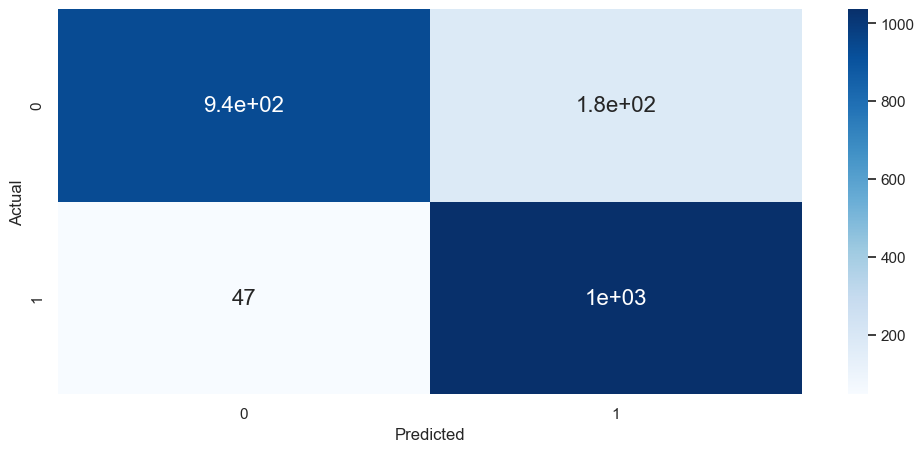

In [111]:
df_cm = pd.DataFrame(confusion_matrix(Y_validation, predictions), columns=np.unique(Y_validation), index = np.unique(Y_validation))
df_cm.index.name = 'Actual'
df_cm.columns.name = 'Predicted'
sns.heatmap(df_cm, cmap="Blues", annot=True,annot_kws={"size": 16})# font sizes

<a id='6.2'></a>
## 7.2. Variable Intuition/Feature Importance
Looking at the details above GBM might be worthy of further study.
Let us look into the Feature Importance of the GBM model

[9.75177877e-03 5.17272234e-03 2.12116351e-02 1.47425136e-02
 3.68306261e-02 1.18180981e-02 5.89584072e-02 3.72054403e-04
 1.76351351e-03 4.24052473e-03 4.79568404e-03 1.32415627e-02
 5.50204945e-03 4.00506212e-03 5.77176577e-03 2.16873872e-03
 7.33623956e-01 1.60595959e-11 1.26245550e-02 7.49822816e-03
 6.15235184e-03 6.47965088e-03 7.47421996e-03 5.42128791e-03
 2.94912831e-03 5.14060867e-03 8.10457206e-03 4.18470450e-03]


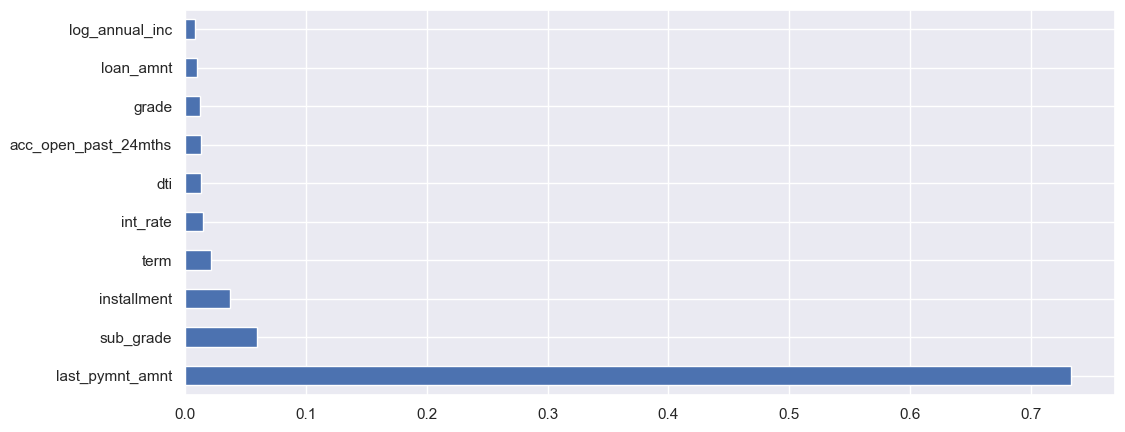

In [112]:
print(model.feature_importances_) #use inbuilt class feature_importances of tree based classifiers
#plot graph of feature importances for better visualization
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances.nlargest(10).plot(kind='barh')
pyplot.show()

__Conclusion__:

We showed that data preparation is one of the most important steps. We addressed
that by performing feature elimination by using different techniques such as subjec‐
tive judgement, correlation, visualization and the data quality of the feature.
We illustrated that there can be different ways of handling and analyzing the categorical data and converting categorical data into model usable format.

Finally, we analyzed the feature importance and found that results of the case study
are quite intuitive.

